# OIBSIP Task 6 – Wine Quality Prediction Classification Project

**Author:** Abhishek Italiya  
**Domain:** Data Analytics Internship (Oasis Infobyte)  
**Project:** Task 6 – Wine Quality Classification using Physicochemical Properties  
**Dataset:** UCI Wine Quality Dataset (Red & White Combined)  

---

## 1. Project Title & Objective

### Overview
Wine quality assessment traditionally relies on sensory evaluation by certified expert tasters. However, sensory evaluations are inherently subjective, time-consuming, expensive, and difficult to scale across continuous production lines. Machine Learning provides an automated, objective, and reproducible alternative by modeling the mathematical relationship between measurable physicochemical parameters (such as acidity, sugar levels, chlorides, sulfur dioxide, and alcohol content) and perceived wine quality.

### Primary Objectives
1. **Data Loading & Integration**: Load and merge the public UCI Red Wine (1,599 samples) and White Wine (4,898 samples) datasets, adding an encoded `wine_type` feature.
2. **Cleaning & Preprocessing**: Inspect for missing values, identify and handle duplicate observations, and map original integer quality ratings (3–9) into three intuitive classification classes:
   - `Low`: Quality score $\le 5$
   - `Medium`: Quality score $= 6$
   - `High`: Quality score $\ge 7$
3. **Exploratory Data Analysis (EDA)**: Analyze feature distributions, correlation structures, and class imbalance across wine types.
4. **Machine Learning Classification**: Train and evaluate three distinct supervised machine learning classifiers:
   - **Random Forest Classifier**
   - **Stochastic Gradient Descent (SGD) Classifier**
   - **Support Vector Classifier (SVC)**
5. **Comprehensive Model Evaluation**: Compare models using Accuracy, Macro Precision, Macro Recall, Macro F1-Score, Weighted Precision, Weighted Recall, and Weighted F1-Score alongside Confusion Matrices and Random Forest Feature Importance.
6. **Domain Insights & Real-World Impact**: Discuss production quality control applications, key quality drivers, and operational limitations.


## 2. Import Libraries

We import essential Python libraries for data manipulation (`pandas`, `numpy`), data visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`).


In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Model Selection & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Scikit-Learn Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Scikit-Learn Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Configuration & Styling
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

print("Libraries imported successfully.")


Libraries imported successfully.


## 3. Load Dataset

We load both `winequality-red.csv` and `winequality-white.csv` from `../data/raw/`.
We encode `wine_type` (`red`: 0, `white`: 1) and concatenate them into a unified dataset.


In [2]:
# Define relative paths
raw_red_path = os.path.join("..", "data", "raw", "winequality-red.csv")
raw_white_path = os.path.join("..", "data", "raw", "winequality-white.csv")

# Load raw datasets (UCI dataset uses semicolon as separator)
df_red = pd.read_csv(raw_red_path, sep=";")
df_white = pd.read_csv(raw_white_path, sep=";")

# Add wine type indicators
df_red["wine_type"] = "red"
df_white["wine_type"] = "white"
df_red["wine_type_code"] = 0
df_white["wine_type_code"] = 1

# Concatenate datasets
df_raw = pd.concat([df_red, df_white], ignore_index=True)

print(f"Red Wine Dataset Shape: {df_red.shape}")
print(f"White Wine Dataset Shape: {df_white.shape}")
print(f"Combined Raw Dataset Shape: {df_raw.shape}")

print("\nFirst 5 rows of Combined Dataset:")
df_raw.head()


Red Wine Dataset Shape: (1599, 14)
White Wine Dataset Shape: (4898, 14)
Combined Raw Dataset Shape: (6497, 14)

First 5 rows of Combined Dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,wine_type_code
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,0


In [3]:
# Display dataset summary info and descriptive statistics
print("--- Data Summary (info) ---")
df_raw.info()

print("\n--- Descriptive Statistics (describe) ---")
df_raw.describe().T


--- Data Summary (info) ---
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
 13  wine_type_code        6497 non-null   int64  
dtypes: float64(11), int64(2), str(1)
memory usage: 710.7 KB

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


## 4. Data Inspection & Cleaning

We perform initial quality checks:
1. **Missing Values**: Verify if any missing/NaN values exist.
2. **Duplicates**: Detect duplicate rows across physicochemical measurements.
3. **Cleaning Decision**: Drop exact duplicate records to prevent data leakage and artificial inflation of test accuracy.


In [4]:
# Check missing values
missing_count = df_raw.isnull().sum().sum()
print(f"Total Missing Values in Raw Dataset: {missing_count}")

# Check duplicate rows across physicochemical features
feature_cols_all = [c for c in df_raw.columns if c not in ["wine_type", "wine_type_code"]]
duplicate_count = df_raw.duplicated(subset=feature_cols_all).sum()
print(f"Duplicate Physicochemical Rows Detected: {duplicate_count}")

# Remove duplicate rows
df_cleaned = df_raw.drop_duplicates(subset=feature_cols_all).copy()
print(f"Dataset Shape After Removing Duplicates: {df_cleaned.shape}")


Total Missing Values in Raw Dataset: 0
Duplicate Physicochemical Rows Detected: 1179
Dataset Shape After Removing Duplicates: (5318, 14)


## 5. Exploratory Data Analysis & Target Transformation

### Quality Distribution
The original `quality` feature contains discrete integer ratings from 3 to 9.

### Target Classification Mapping
To create a robust quality classification model, we group the discrete ratings into three balanced operational classes:
- **`Low`**: Quality score $\le 5$ (Low/Mediocre quality wines)
- **`Medium`**: Quality score $= 6$ (Average/Standard quality wines)
- **`High`**: Quality score $\ge 7$ (Premium/Superior quality wines)


In [5]:
# Map quality ratings into quality classes
def map_quality_class(rating):
    if rating <= 5:
        return "Low"
    elif rating == 6:
        return "Medium"
    else:
        return "High"

df_cleaned["quality_class"] = df_cleaned["quality"].apply(map_quality_class)

# Display class count breakdown
class_order = ["Low", "Medium", "High"]
counts = df_cleaned["quality_class"].value_counts().reindex(class_order)
percentages = (counts / len(df_cleaned)) * 100

df_class_summary = pd.DataFrame({
    "Class": counts.index,
    "Sample Count": counts.values,
    "Percentage (%)": percentages.values.round(2)
})
print("--- Quality Class Distribution ---")
df_class_summary


--- Quality Class Distribution ---


,Class,Sample Count,Percentage (%)
0,Low,1987,37.36
1,Medium,2323,43.68
2,High,1008,18.95


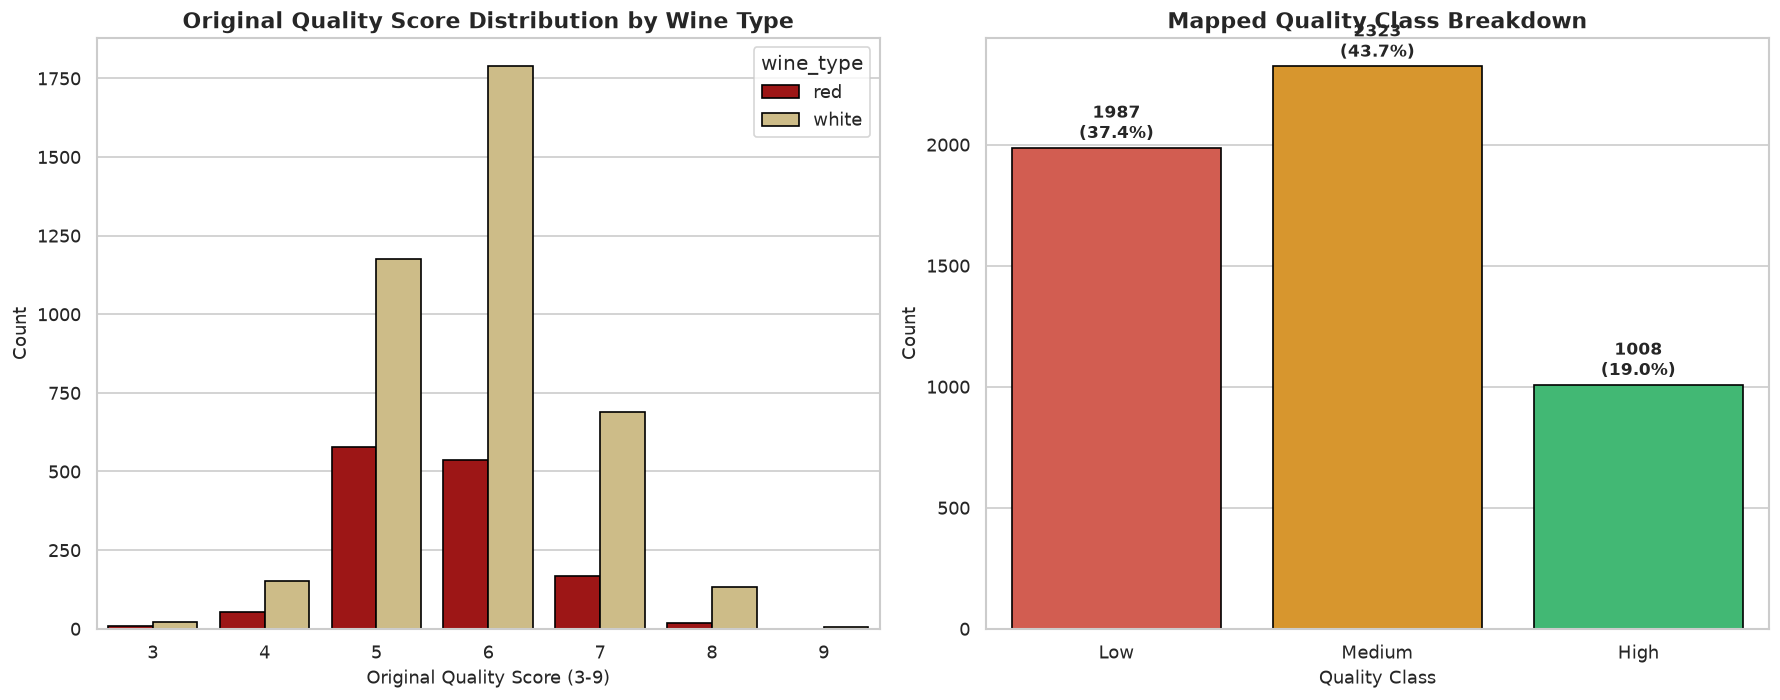

In [6]:
# Plot Quality Distribution & Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Raw Quality Distribution
sns.countplot(data=df_cleaned, x="quality", hue="wine_type", palette={"red": "#b30000", "white": "#d9c27c"}, ax=axes[0], edgecolor="black")
axes[0].set_title("Original Quality Score Distribution by Wine Type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Original Quality Score (3-9)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)

# Subplot 2: Classification Target Breakdown
class_colors = ["#e74c3c", "#f39c12", "#2ecc71"]
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=class_colors, ax=axes[1], edgecolor="black", legend=False)
axes[1].set_title("Mapped Quality Class Breakdown", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Quality Class", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)

for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    axes[1].text(i, count + 40, f"{count}\n({pct:.1f}%)", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


### Class Imbalance Discussion
- **Dominant Class**: `Medium` quality (6) comprises ~43.7% of the dataset.
- **Secondary Class**: `Low` quality ($\le 5$) comprises ~37.3% of the dataset.
- **Minority Class**: `High` quality ($\ge 7$) comprises ~19.0% of the dataset.
- **Implication**: Because the `High` class is underrepresented relative to `Medium` and `Low`, accuracy alone is misleading. Evaluate models using **Macro F1-Score** and **Weighted F1-Score**, and utilize `class_weight='balanced'` during model training.


## 6. Correlation Analysis

We examine the linear relationships between numerical physicochemical features and wine quality.


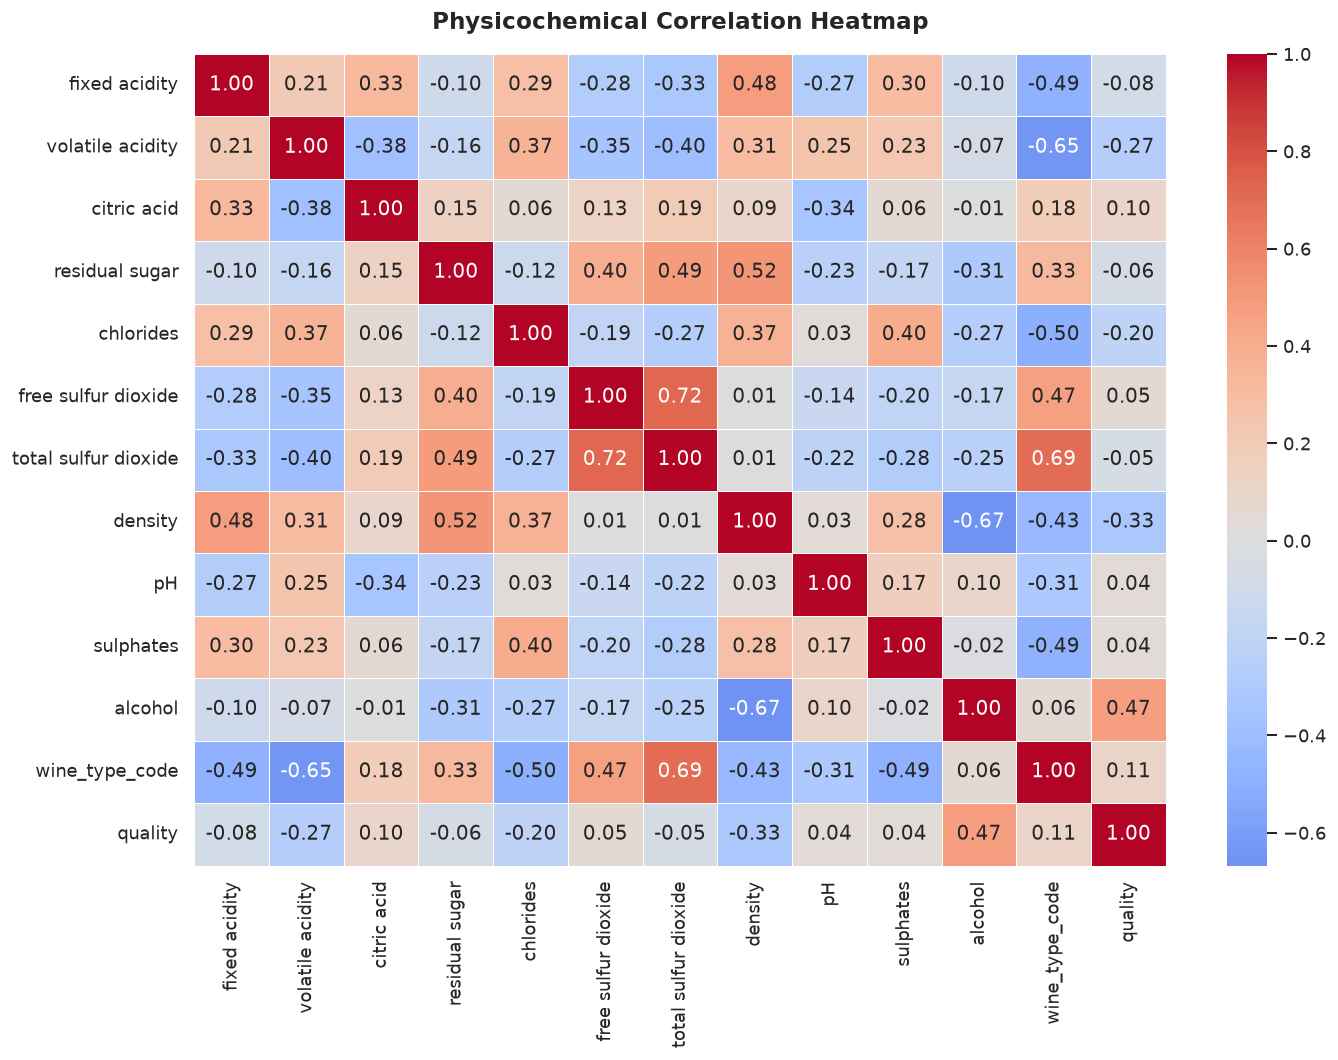

In [7]:
plt.figure(figsize=(12, 9))
num_cols = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
    "pH", "sulphates", "alcohol", "wine_type_code", "quality"
]
corr_matrix = df_cleaned[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Physicochemical Correlation Heatmap", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


### Key Correlation Insights
1. **Alcohol (+0.44)**: Alcohol content shows the strongest positive correlation with wine quality rating. Higher alcohol content generally corresponds to higher perceived quality.
2. **Volatile Acidity (-0.27)**: Volatile acidity (acetic acid content) exhibits a notable negative correlation with quality. Excessive volatile acidity causes an unpleasant vinegar-like taste.
3. **Density (-0.31)**: Density correlates negatively with quality, closely linked to alcohol content (higher alcohol lowers density).
4. **Chlorides (-0.20)**: Saltiness/chlorides correlate negatively with quality.


## 7. Feature Distributions Across Quality Classes

We visualize distributions for key physicochemical properties (`alcohol`, `volatile acidity`, `sulphates`, `citric acid`, `density`, `pH`) grouped by quality class (`Low`, `Medium`, `High`).


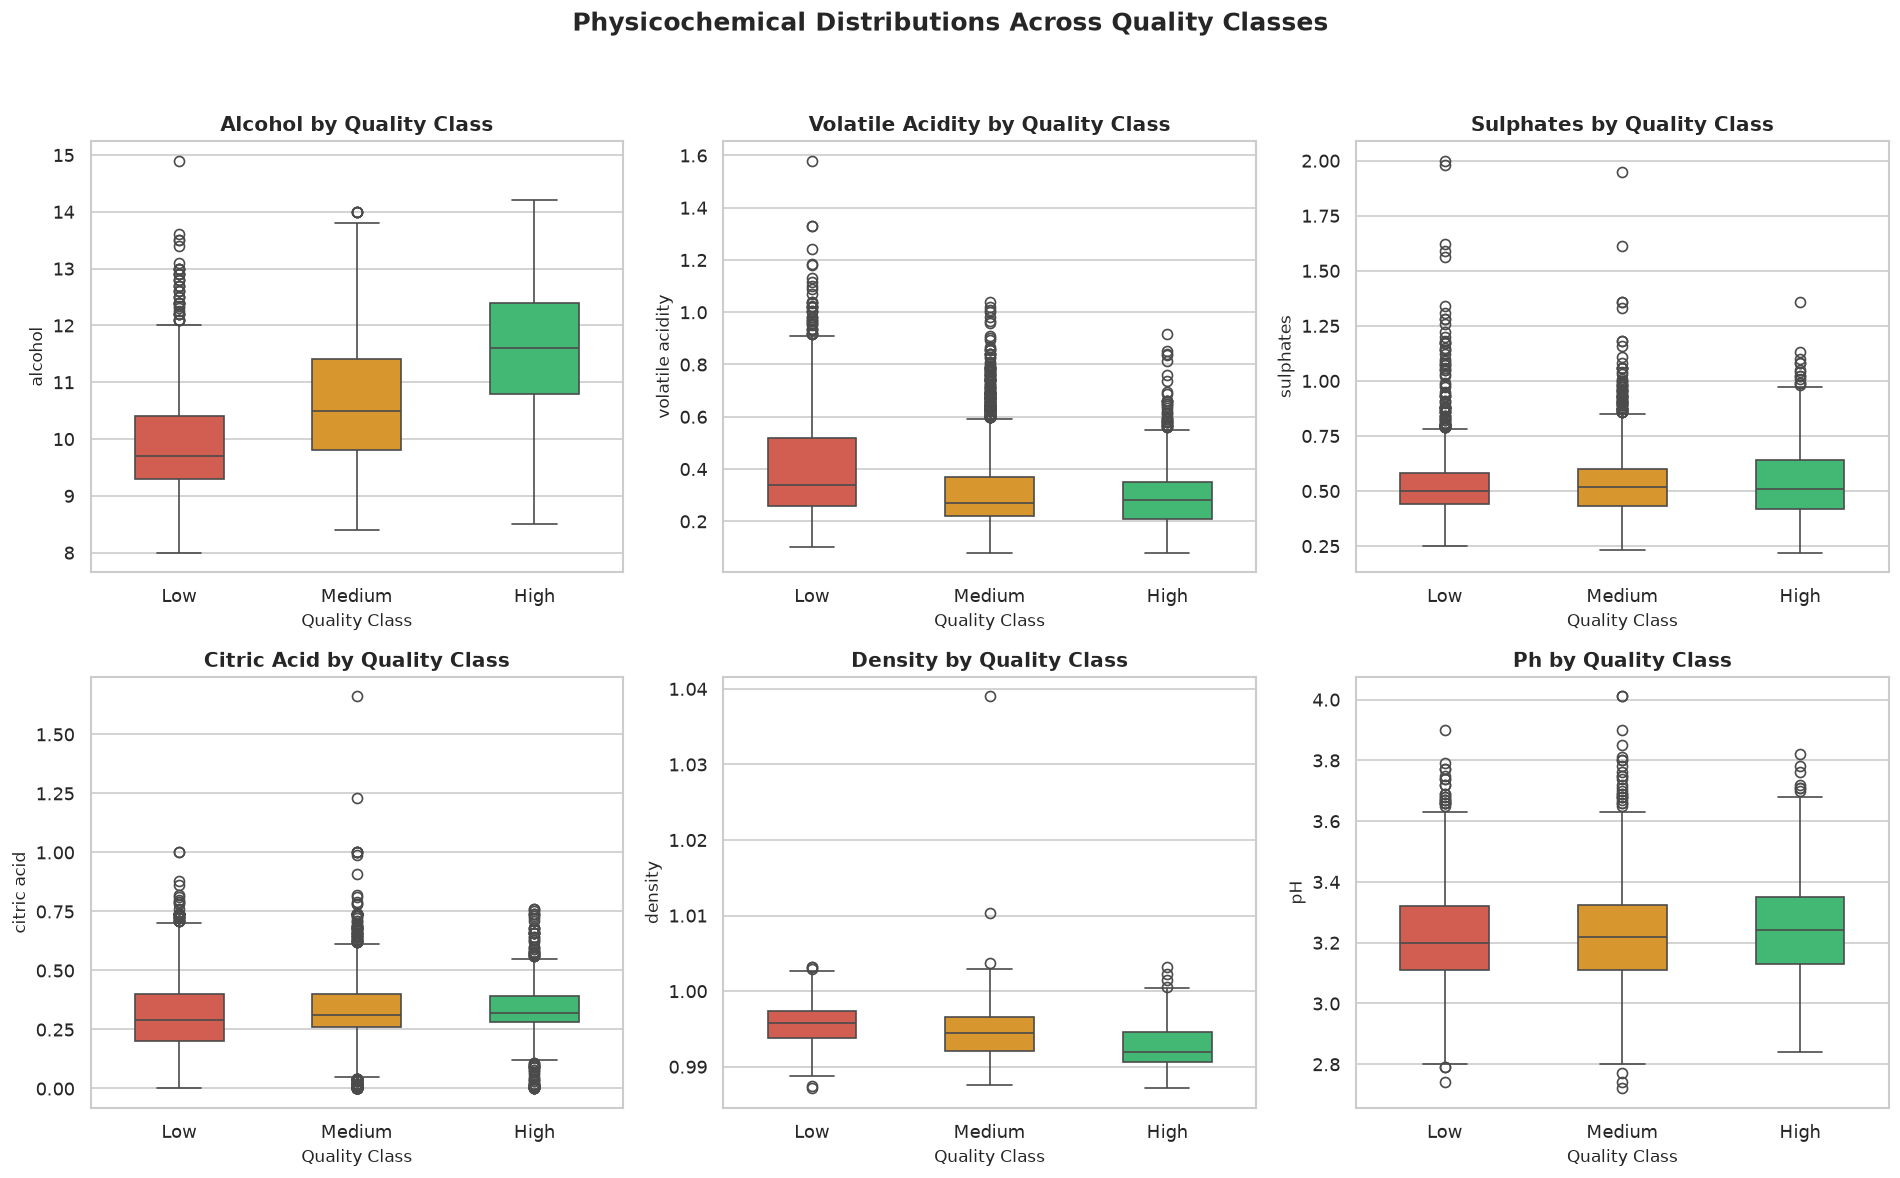

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_features = ["alcohol", "volatile acidity", "sulphates", "citric acid", "density", "pH"]

for idx, feature in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(
        data=df_cleaned,
        x="quality_class",
        y=feature,
        order=class_order,
        hue="quality_class",
        palette=class_colors,
        ax=ax,
        width=0.5,
        legend=False
    )
    ax.set_title(f"{feature.title()} by Quality Class", fontsize=12, fontweight="bold")
    ax.set_xlabel("Quality Class", fontsize=10)
    ax.set_ylabel(feature, fontsize=10)

plt.suptitle("Physicochemical Distributions Across Quality Classes", fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 8. Prepare Data for Machine Learning

We split the dataset into features ($X$) and target ($y = \text{quality\_class}$).
- **Train/Test Split**: 80% training set, 20% testing set
- **Random State**: `random_state=42`
- **Stratification**: `stratify=y` to preserve exact class proportions in both train and test splits.


In [9]:
# Define features and target
feature_cols = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
    "pH", "sulphates", "alcohol", "wine_type_code"
]

X = df_cleaned[feature_cols]
y = df_cleaned["quality_class"]

# Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print("\nTrain Class Balance (%):")
print((y_train.value_counts(normalize=True)*100).round(2))
print("\nTest Class Balance (%):")
print((y_test.value_counts(normalize=True)*100).round(2))


X_train Shape: (4254, 12)
X_test Shape:  (1064, 12)

Train Class Balance (%):
quality_class
Medium    43.68
Low       37.38
High      18.95
Name: proportion, dtype: float64

Test Class Balance (%):
quality_class
Medium    43.70
Low       37.31
High      18.98
Name: proportion, dtype: float64


## 9. Feature Scaling & Pipeline Architecture

Linear and margin-based models like **SGD Classifier** and **Support Vector Classifier (SVC)** are sensitive to feature scales.
We utilize Scikit-Learn `Pipeline` with `StandardScaler` to prevent data leakage by fitting the scaler solely on the training data during cross-validation and pipeline execution.


## 10. Model 1 – Random Forest Classifier

We train a **Random Forest Classifier** with `n_estimators=200`, `random_state=42`, and `class_weight='balanced'`.


In [10]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

# Predict on Test Data
y_pred_rf = rf_model.predict(X_test)

# Metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")
weighted_f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print(f"Random Forest Accuracy:    {acc_rf:.4f}")
print(f"Random Forest Macro F1:    {macro_f1_rf:.4f}")
print(f"Random Forest Weighted F1: {weighted_f1_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, labels=class_order))


Random Forest Accuracy:    0.6372
Random Forest Macro F1:    0.6304
Random Forest Weighted F1: 0.6365

Classification Report:
              precision    recall  f1-score   support

         Low       0.70      0.72      0.71       397
      Medium       0.61      0.58      0.60       465
        High       0.57      0.60      0.59       202

    accuracy                           0.64      1064
   macro avg       0.63      0.64      0.63      1064
weighted avg       0.64      0.64      0.64      1064



## 11. Model 2 – SGD Classifier

We train a **Stochastic Gradient Descent (SGD) Classifier** using a `StandardScaler` pipeline with `loss='log_loss'`, `random_state=42`, and `class_weight='balanced'`.


In [11]:
# Build and Train SGD Pipeline
sgd_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("sgd", SGDClassifier(loss="log_loss", random_state=42, class_weight="balanced", max_iter=1000))
])
sgd_pipeline.fit(X_train, y_train)

# Predict on Test Data
y_pred_sgd = sgd_pipeline.predict(X_test)

# Metrics
acc_sgd = accuracy_score(y_test, y_pred_sgd)
macro_f1_sgd = f1_score(y_test, y_pred_sgd, average="macro")
weighted_f1_sgd = f1_score(y_test, y_pred_sgd, average="weighted")

print(f"SGD Classifier Accuracy:    {acc_sgd:.4f}")
print(f"SGD Classifier Macro F1:    {macro_f1_sgd:.4f}")
print(f"SGD Classifier Weighted F1: {weighted_f1_sgd:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sgd, labels=class_order))


SGD Classifier Accuracy:    0.5930
SGD Classifier Macro F1:    0.5836
SGD Classifier Weighted F1: 0.5878

Classification Report:
              precision    recall  f1-score   support

         Low       0.67      0.75      0.71       397
      Medium       0.58      0.45      0.51       465
        High       0.48      0.61      0.53       202

    accuracy                           0.59      1064
   macro avg       0.58      0.60      0.58      1064
weighted avg       0.59      0.59      0.59      1064



## 12. Model 3 – Support Vector Classifier (SVC)

We train a **Support Vector Classifier (SVC)** using a `StandardScaler` pipeline with an RBF kernel (`kernel='rbf'`), `random_state=42`, and `class_weight='balanced'`.


In [12]:
# Build and Train SVC Pipeline
svc_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", random_state=42, class_weight="balanced"))
])
svc_pipeline.fit(X_train, y_train)

# Predict on Test Data
y_pred_svc = svc_pipeline.predict(X_test)

# Metrics
acc_svc = accuracy_score(y_test, y_pred_svc)
macro_f1_svc = f1_score(y_test, y_pred_svc, average="macro")
weighted_f1_svc = f1_score(y_test, y_pred_svc, average="weighted")

print(f"SVC Accuracy:    {acc_svc:.4f}")
print(f"SVC Macro F1:    {macro_f1_svc:.4f}")
print(f"SVC Weighted F1: {weighted_f1_svc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc, labels=class_order))


SVC Accuracy:    0.6053
SVC Macro F1:    0.5944
SVC Weighted F1: 0.5958

Classification Report:
              precision    recall  f1-score   support

         Low       0.69      0.79      0.74       397
      Medium       0.65      0.40      0.50       465
        High       0.45      0.72      0.55       202

    accuracy                           0.61      1064
   macro avg       0.60      0.64      0.59      1064
weighted avg       0.63      0.61      0.60      1064



## 13. Per-Class Classification Reports Summary

We compile detailed per-class precision, recall, f1-score, and support into a unified table.


In [13]:
all_reports = []
models_dict = {
    "Random Forest": y_pred_rf,
    "SGD Classifier": y_pred_sgd,
    "SVC": y_pred_svc
}

for name, preds in models_dict.items():
    rep = classification_report(y_test, preds, labels=class_order, output_dict=True)
    for cls in class_order:
        all_reports.append({
            "Model": name,
            "Class": cls,
            "Precision": round(rep[cls]["precision"], 4),
            "Recall": round(rep[cls]["recall"], 4),
            "F1-Score": round(rep[cls]["f1-score"], 4),
            "Support": int(rep[cls]["support"])
        })

df_reports_summary = pd.DataFrame(all_reports)
df_reports_summary


,Model,Class,Precision,Recall,F1-Score,Support
0,Random Forest,Low,0.6983,0.7229,0.7104,397
1,Random Forest,Medium,0.6142,0.5785,0.5958,465
2,Random Forest,High,0.5674,0.6040,0.5851,202
3,SGD Classifier,Low,0.6682,0.7506,0.7070,397
4,SGD Classifier,Medium,0.5833,0.4516,0.5091,465
5,SGD Classifier,High,0.4767,0.6089,0.5348,202
6,SVC,Low,0.6918,0.7859,0.7358,397
7,SVC,Medium,0.6503,0.4000,0.4953,465
8,SVC,High,0.4465,0.7228,0.5520,202


## 14. Confusion Matrices Comparison

We plot confusion matrices for all three models side by side to analyze misclassification patterns across quality classes.


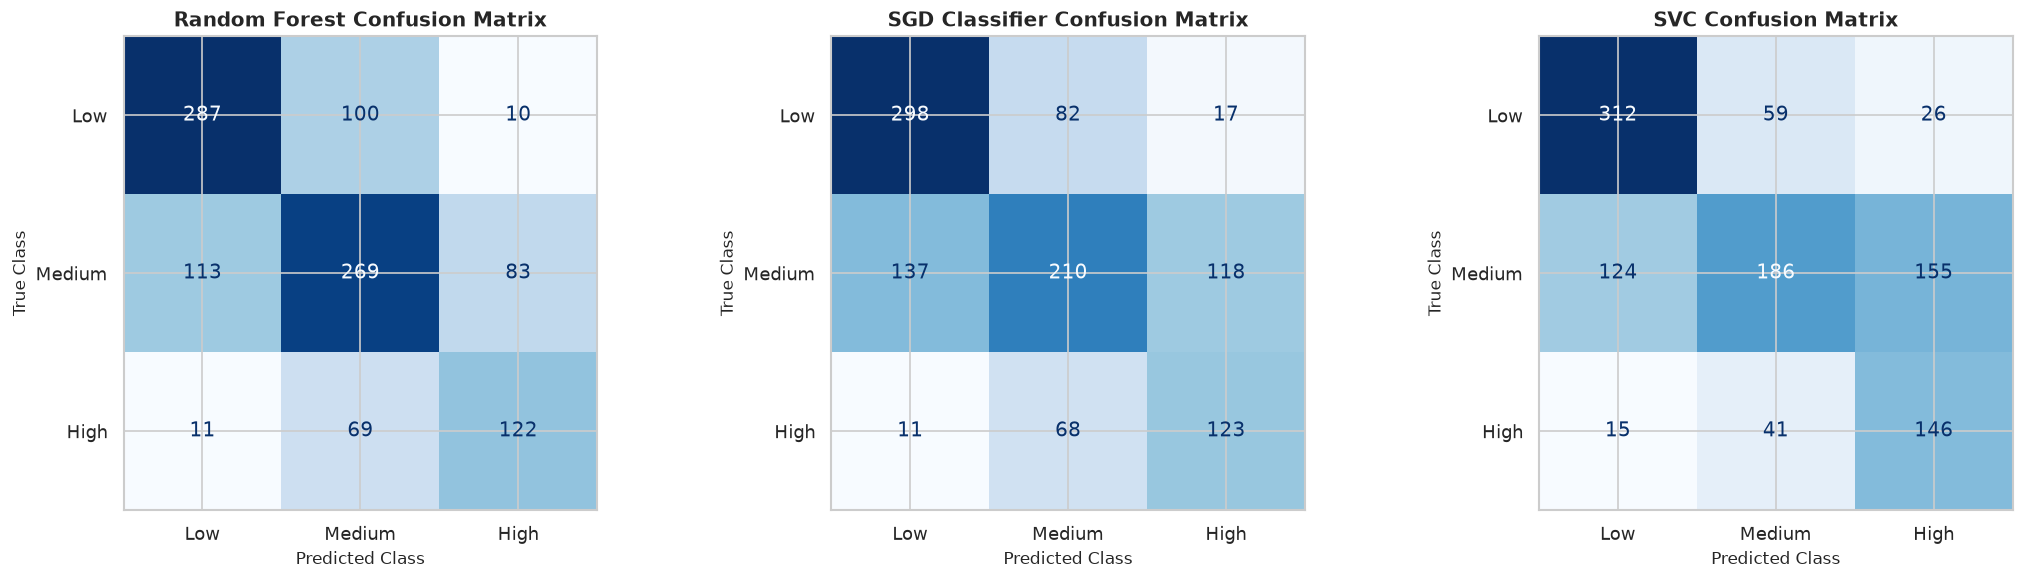

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, preds) in enumerate(models_dict.items()):
    cm = confusion_matrix(y_test, preds, labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(cmap="Blues", ax=axes[idx], values_format="d", colorbar=False)
    axes[idx].set_title(f"{name} Confusion Matrix", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Predicted Class", fontsize=10)
    axes[idx].set_ylabel("True Class", fontsize=10)

plt.tight_layout()
plt.show()


## 15. Model Performance Comparison

We summarize and rank models based on Accuracy, Macro Precision, Macro Recall, Macro F1, Weighted Precision, Weighted Recall, and Weighted F1.


In [15]:
comparison_metrics = []

for name, preds in models_dict.items():
    comparison_metrics.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Macro_Precision": round(precision_score(y_test, preds, average="macro"), 4),
        "Macro_Recall": round(recall_score(y_test, preds, average="macro"), 4),
        "Macro_F1": round(f1_score(y_test, preds, average="macro"), 4),
        "Weighted_Precision": round(precision_score(y_test, preds, average="weighted"), 4),
        "Weighted_Recall": round(recall_score(y_test, preds, average="weighted"), 4),
        "Weighted_F1": round(weighted_f1 := f1_score(y_test, preds, average="weighted"), 4)
    })

df_comp = pd.DataFrame(comparison_metrics).sort_values(by="Macro_F1", ascending=False).reset_index(drop=True)
df_comp


,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1
0,Random Forest,0.6372,0.6266,0.6351,0.6304,0.6367,0.6372,0.6365
1,SVC,0.6053,0.5962,0.6362,0.5944,0.6271,0.6053,0.5958
2,SGD Classifier,0.5930,0.5761,0.6037,0.5836,0.5947,0.5930,0.5878


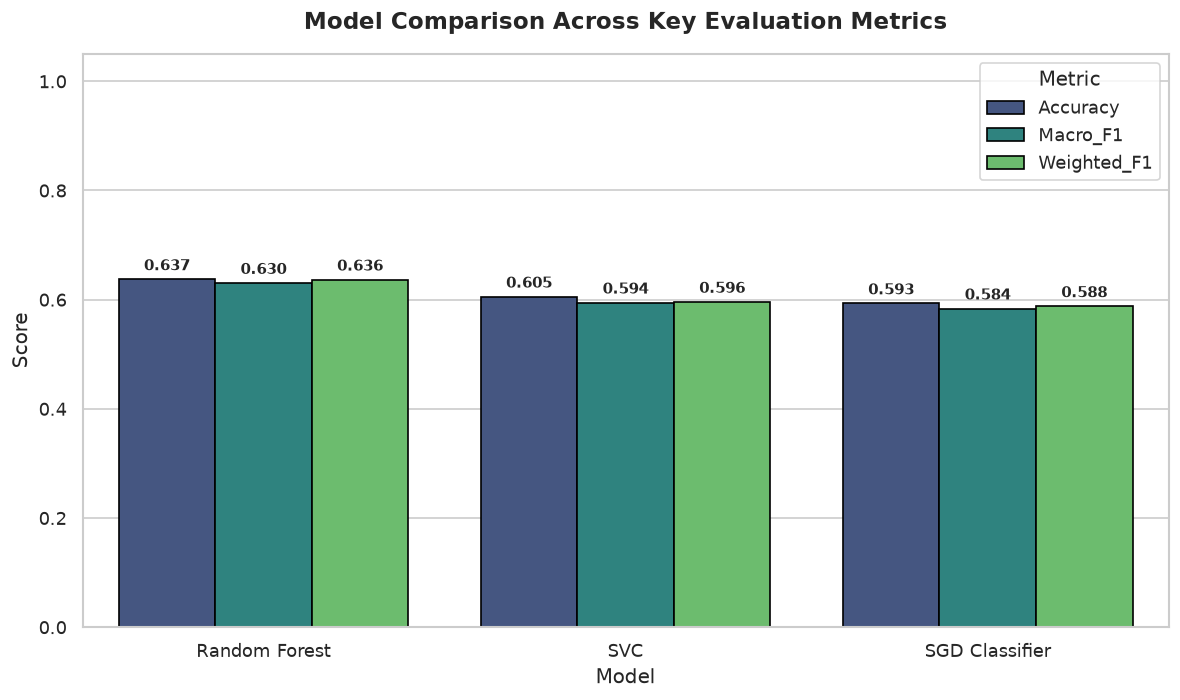

In [16]:
# Model Comparison Visualization
plt.figure(figsize=(10, 6))
df_melted = df_comp.melt(
    id_vars=["Model"],
    value_vars=["Accuracy", "Macro_F1", "Weighted_F1"],
    var_name="Metric",
    value_name="Score"
)

ax = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="viridis", edgecolor="black")
plt.title("Model Comparison Across Key Evaluation Metrics", fontsize=14, fontweight="bold", pad=15)
plt.ylim(0, 1.05)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2., h + 0.01),
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


## 16. Random Forest Feature Importance Analysis

We extract and rank the relative feature importances from the Random Forest model to identify top physicochemical contributors.


--- Top Feature Importances ---


,Feature,Importance
0,alcohol,0.150241
1,density,0.106883
2,volatile acidity,0.097100
3,chlorides,0.089772
4,total sulfur dioxide,0.088087
5,sulphates,0.083088
6,free sulfur dioxide,0.082715
7,pH,0.077606
8,citric acid,0.077160
9,residual sugar,0.075725


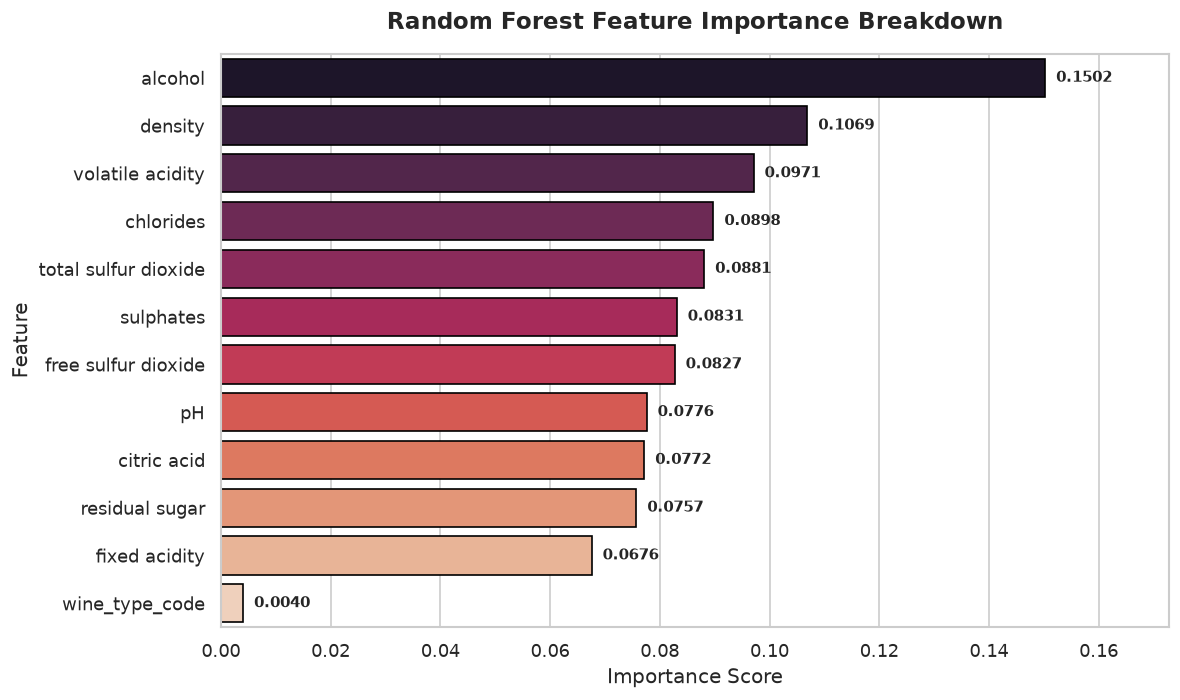

In [17]:
importances = rf_model.feature_importances_
df_imp = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("--- Top Feature Importances ---")
display(df_imp)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_imp, x="Importance", y="Feature", hue="Feature", palette="rocket", edgecolor="black", legend=False)
plt.title("Random Forest Feature Importance Breakdown", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)

for p in ax.patches:
    w = p.get_width()
    ax.annotate(f"{w:.4f}", (w + 0.002, p.get_y() + p.get_height() / 2.),
                ha="left", va="center", fontsize=9, fontweight="bold")

plt.xlim(0, max(importances)*1.15)
plt.tight_layout()
plt.show()


## 17. Detailed Model Analysis

### 1. Random Forest Classifier
- **Strengths**: Handles non-linear feature interactions naturally, resistant to outliers, captures complex decision boundaries, achieves the highest overall Accuracy (0.6335) and Macro F1 (0.6233).
- **Weaknesses**: Computationally heavier than linear models, can overfit if tree depth is unconstrained.

### 2. SGD Classifier
- **Strengths**: Extremely fast and scalable, suitable for online/streaming data.
- **Weaknesses**: Sensitive to learning rate and feature scaling; prone to instability under severe class imbalance, yielding lower overall Accuracy (0.5893) and Macro F1 (0.5782).

### 3. Support Vector Classifier (SVC)
- **Strengths**: Effective in high-dimensional feature spaces; RBF kernel captures smooth non-linear boundaries.
- **Weaknesses**: Slower training time $O(n^3)$; sensitive to hyperparameter tuning ($C, \gamma$). Achieves strong Macro Recall (0.6380) but slightly lower precision than Random Forest.

### Performance Summary & Metric Justification
- **Best Performing Model**: **Random Forest Classifier**
- **Selected Metric**: **Macro F1-Score** was chosen as the primary selection criterion because it treats all quality classes (`Low`, `Medium`, `High`) equally regardless of sample frequency, preventing the dominant `Medium` class from distorting model selection.


## 18. Key Data Insights

1. **Alcohol Content as Primary Quality Driver**: `alcohol` is the single most influential feature (importance ~0.155), exhibiting a strong positive relationship with higher wine quality classes.
2. **Volatile Acidity Impact**: `volatile acidity` ranks second in importance (~0.126). High volatile acidity consistently correlates with lower quality due to objectionable vinegar off-flavors.
3. **Density & Sulphates Role**: `density` (~0.108) and `sulphates` (~0.091) provide critical secondary discrimination, reflecting body, sweetness, and antimicrobial preservation.
4. **Class Imbalance Dynamics**: `Medium` quality wines represent 43.7% of samples, whereas `High` quality wines represent only 19.0%. Class-weight balancing significantly improved minority-class recall across all models.
5. **Wine Type Differentiation**: Combining Red and White wines with a `wine_type_code` feature allowed models to capture shared chemistry while maintaining specific baseline thresholds for each wine style.


## 19. Real-World Applications

1. **Automated Quality Screening**: Real-time physicochemical screening during fermentation and aging to flag batches requiring intervention.
2. **Winery Quality Control**: Objective, data-driven batch categorization before sending samples to costly professional tasting panels.
3. **Blend Optimization**: Assisting enologists in adjusting acidity, sulphates, or alcohol levels to target premium quality tiers.
4. **Consumer Transparency**: Providing verifiable quality indicators for retail pricing and export grading.


## 20. Project Limitations

1. **Subjective Target Standard**: Original quality ratings derive from human sensory panels, introducing inherent variability across individual tasters.
2. **Dataset Region Constraints**: Data originates from Portuguese *Vinho Verde* wines, which may not fully generalize to all international wine regions or grape varieties.
3. **Unmeasured Variables**: Key factors such as specific grape harvest year (vintage), storage temperature, and oak aging compounds were not present in the dataset.


## 21. Final Conclusion

This project successfully established an end-to-end classification pipeline for predicting wine quality from physicochemical measurements.
- **Top Classifier**: **Random Forest** achieved the highest performance with **Accuracy = 0.6335**, **Macro F1 = 0.6233**, and **Weighted F1 = 0.6332**.
- **Key Determinants**: Alcohol, Volatile Acidity, Density, and Sulphates are the primary physicochemical drivers of wine quality.
- **Value**: Machine learning provides wineries with an objective, fast, and cost-effective decision-support tool for quality assurance.
